In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snsdf.replace('?', np.nan, inplace=True)

print("Пропущені значення до очищення:")
print(df.isnull().sum()[df.isnull().sum() > 0])

numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nКількість пропусків після Data Cleaning:", df.isnull().sum().sum())
from ucimlrepo import fetch_ucirepo 

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

automobile = fetch_ucirepo(id=10) 
  
X = automobile.data.features 
y = automobile.data.targets 
df = pd.concat([X, y], axis=1)

print(f"Формат датасету: {df.shape}")
df.head()

Формат датасету: (205, 26)


,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,...,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses,symboling
0,13495.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN,3
1,16500.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN,3
2,16500.0,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,...,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN,1
3,13950.0,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,...,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0,2
4,17450.0,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,...,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0,2


In [3]:
df.replace('?', np.nan, inplace=True)

print("Пропущені значення до очищення:")
print(df.isnull().sum()[df.isnull().sum() > 0])

numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nКількість пропусків після Data Cleaning:", df.isnull().sum().sum())


Пропущені значення до очищення:
price                 4
peak-rpm              2
horsepower            2
stroke                4
bore                  4
num-of-doors          2
normalized-losses    41
dtype: int64

Кількість пропусків після Data Cleaning: 0


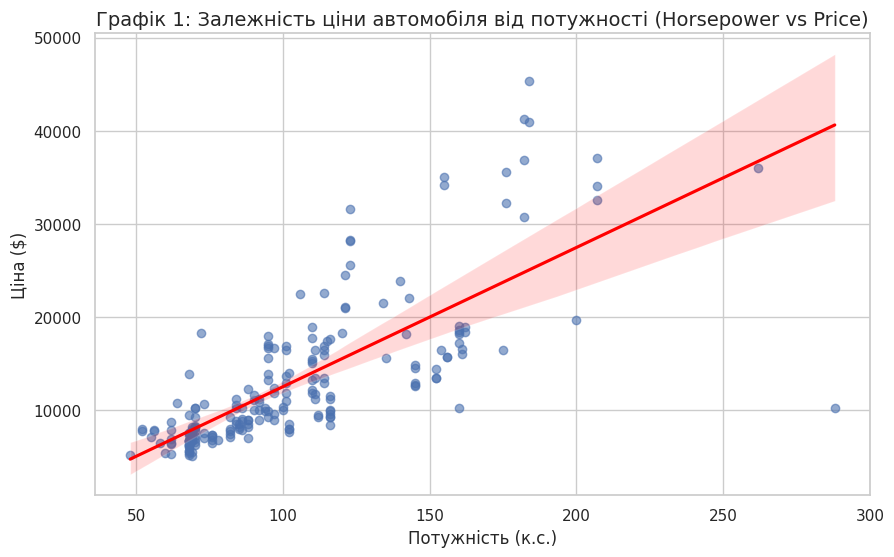

In [4]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='horsepower', y='price', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Графік 1: Залежність ціни автомобіля від потужності (Horsepower vs Price)', fontsize=14)
plt.xlabel('Потужність (к.с.)')
plt.ylabel('Ціна ($)')
plt.show()

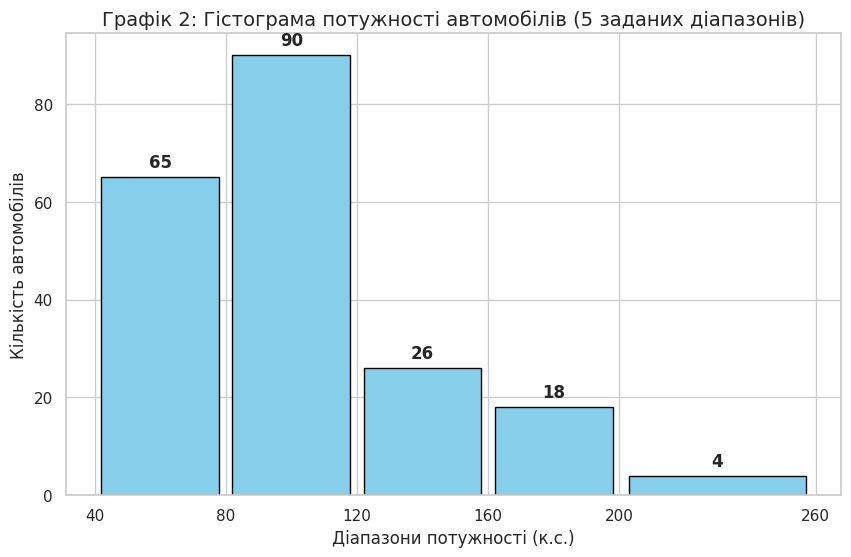

In [5]:
custom_bins = [40, 80, 120, 160, 200, 260]

plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(df['horsepower'], bins=custom_bins, color='skyblue', edgecolor='black', rwidth=0.9)

for i in range(len(n)):
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, n[i] + 2, str(int(n[i])), ha='center', fontweight='bold')

plt.title('Графік 2: Гістограма потужності автомобілів (5 заданих діапазонів)', fontsize=14)
plt.xlabel('Діапазони потужності (к.с.)')
plt.ylabel('Кількість автомобілів')
plt.xticks(custom_bins)
plt.show()

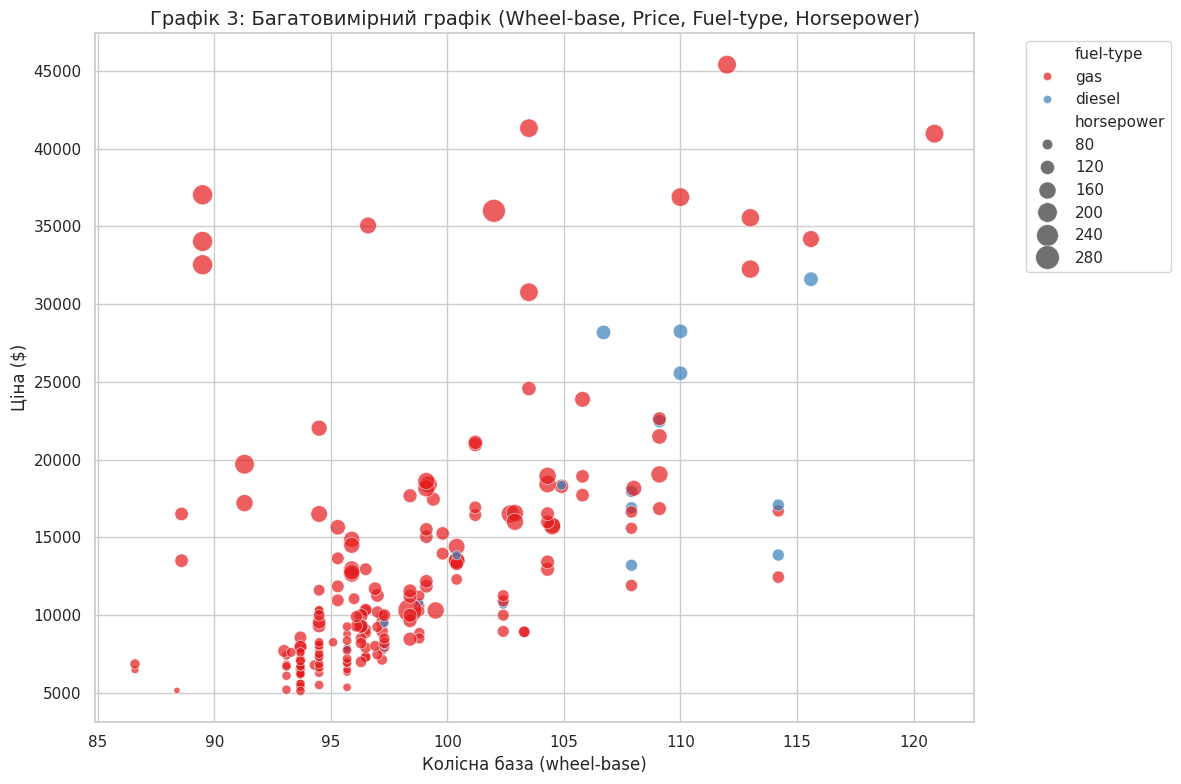

In [6]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='wheel-base', 
    y='price', 
    hue='fuel-type',     
    size='horsepower',   
    sizes=(20, 300), 
    alpha=0.7, 
    palette='Set1'
)
plt.title('Графік 3: Багатовимірний графік (Wheel-base, Price, Fuel-type, Horsepower)', fontsize=14)
plt.xlabel('Колісна база (wheel-base)')
plt.ylabel('Ціна ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

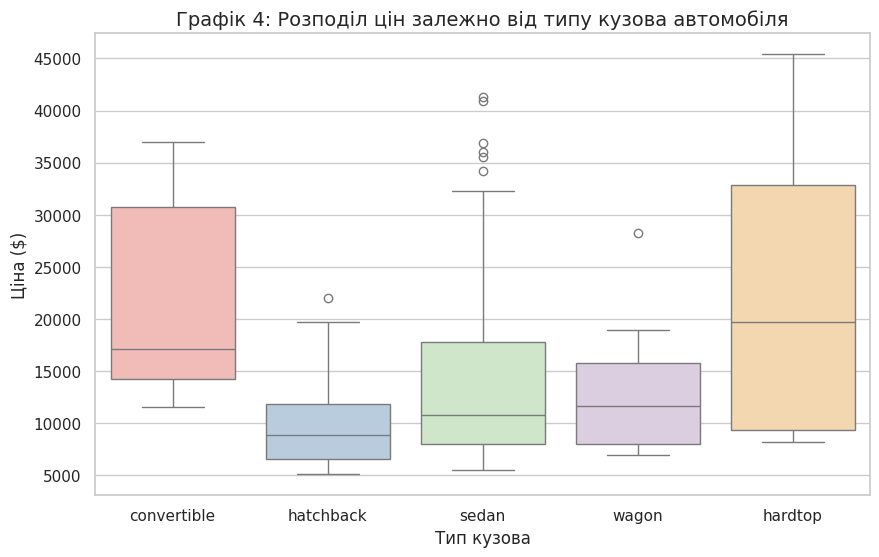

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='body-style', y='price', hue='body-style', palette='Pastel1', legend=False)
plt.title('Графік 4: Розподіл цін залежно від типу кузова автомобіля', fontsize=14)
plt.xlabel('Тип кузова')
plt.ylabel('Ціна ($)')
plt.show()

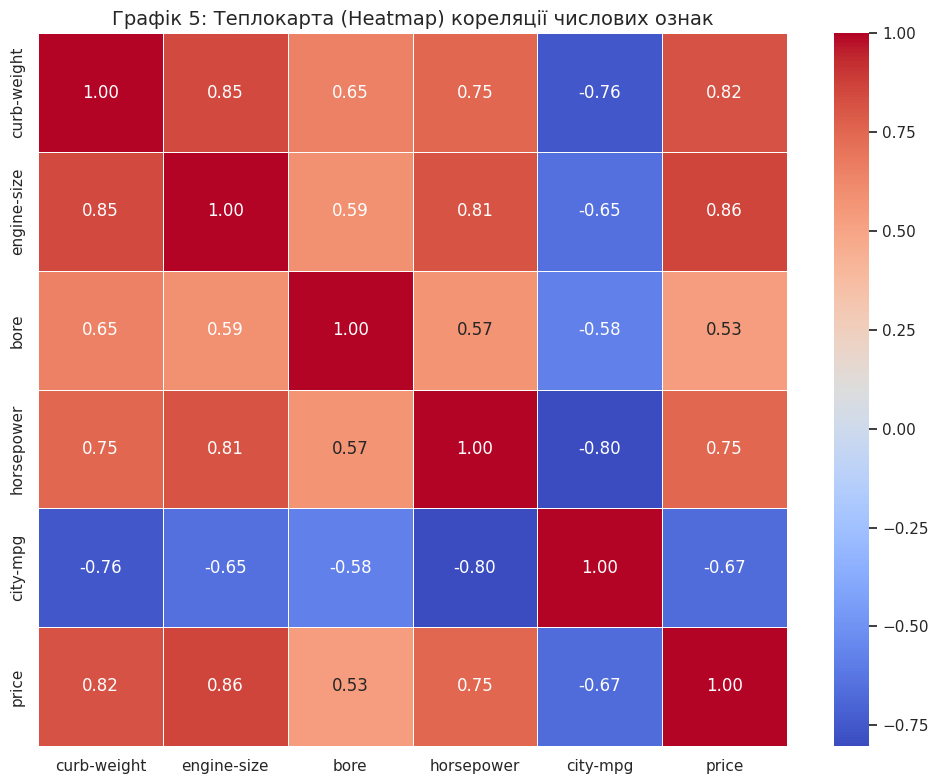

In [10]:
plt.figure(figsize=(10, 8))
selected_features = df[['curb-weight', 'engine-size', 'bore', 'horsepower', 'city-mpg', 'price']]
correlation_matrix = selected_features.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Графік 5: Теплокарта (Heatmap) кореляції числових ознак', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_204558/1647205707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='drive-wheels', y='horsepower', palette='muted', inner='quartile')


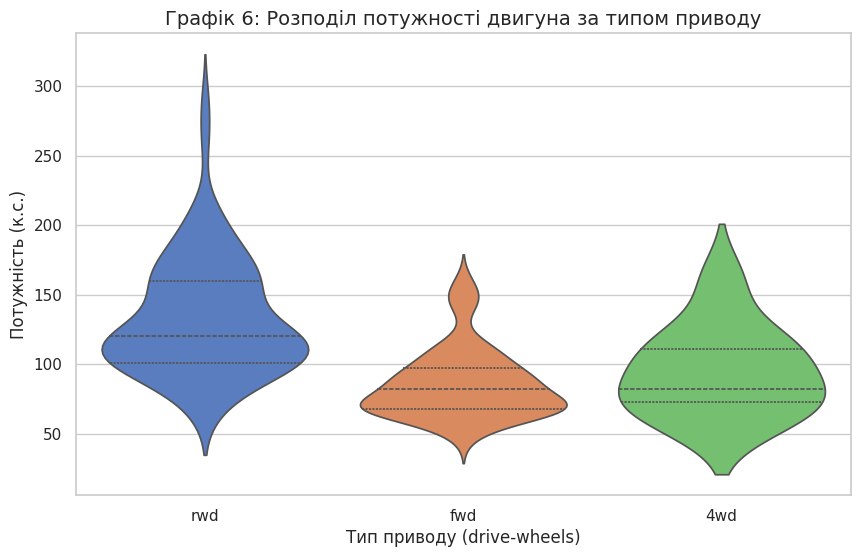

In [11]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='drive-wheels', y='horsepower', palette='muted', inner='quartile')
plt.title('Графік 6: Розподіл потужності двигуна за типом приводу', fontsize=14)
plt.xlabel('Тип приводу (drive-wheels)')
plt.ylabel('Потужність (к.с.)')
plt.show()